In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("houses.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

Dataset Shape: (200, 4)

First 5 rows:
   size  rooms  age  price
0  17.9      4   26  113.7
1  23.0      5    7  173.3
2  20.7      3   30   80.6
3  10.3      4   30   59.2
4  11.7      2   29   47.3

Missing values:
 size     0
rooms    0
age      0
price    0
dtype: int64


In [ ]:
df["size_per_room"] = df["size"] / df["rooms"]

feats = ["size", "rooms", "age", "size_per_room"]
X = df[feats]
y = df["price"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train rows: {len(Xtr)} | Test rows: {len(Xte)}")

Train rows: 150 | Test rows: 50


Test R²  : 0.8714
Test RMSE: 11.68


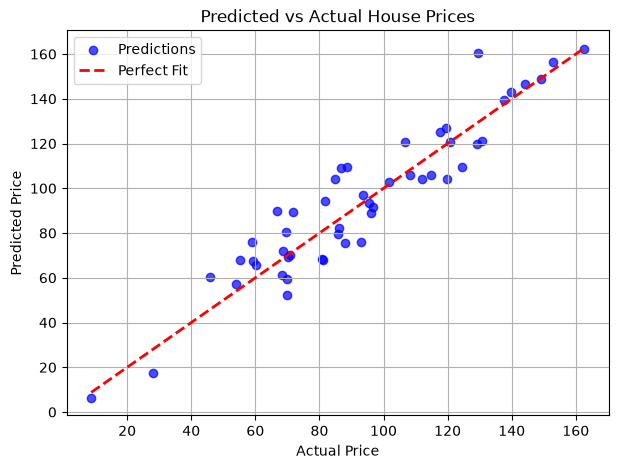

In [ ]:
model = LinearRegression()
model.fit(Xtr, ytr)

pred = model.predict(Xte)

rmse = np.sqrt(mean_squared_error(yte, pred))
r2 = r2_score(yte, pred)

print(f"Test R²  : {r2:.4f}")
print(f"Test RMSE: {rmse:.2f}")

plt.figure(figsize=(7, 5))
plt.scatter(yte, pred, alpha=0.7, color="blue", label="Predictions")
plt.plot([yte.min(), yte.max()], [yte.min(), yte.max()], "r--", lw=2, label="Perfect Fit")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual House Prices")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
coef_summary = pd.DataFrame({
    "Feature": feats,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Intercept:", model.intercept_)
print("\nCoefficients:")
print(coef_summary.to_string(index=False))

Intercept: 19.438511432049097

Coefficients:
      Feature  Coefficient
        rooms    16.224040
         size     3.109713
size_per_room     0.430144
          age    -1.435279
